In [1]:
!pip install tensorflow nltk matplotlib


In [2]:
from google.colab import files
files.upload()  # Upload the 'kaggle.json' file here


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"chatgpt406788","key":"ea9410ba860d25c871be454141132ae4"}'}

In [6]:
import os

# Ensure that the destination directory exists
os.makedirs('/root/.kaggle', exist_ok=True)

# Move the kaggle.json file to the correct location
os.rename("kaggle.json", "/root/.kaggle/kaggle.json")

# Set permissions to read the file
!chmod 600 /root/.kaggle/kaggle.json


In [7]:
!pip install kaggle


In [8]:
!kaggle datasets download -d wcukierski/enron-email-dataset


Dataset URL: https://www.kaggle.com/datasets/wcukierski/enron-email-dataset
License(s): copyright-authors


In [9]:
!unzip enron-email-dataset.zip -d /content/enron_data


Archive:  enron-email-dataset.zip
  inflating: /content/enron_data/emails.csv  


In [11]:
# List the contents of the unzipped directory
import os
os.listdir('/content/enron_data')


['emails.csv']

In [12]:
import pandas as pd

# Load the dataset into a DataFrame
df = pd.read_csv('/content/enron_data/emails.csv')

# Preview the dataset to check its structure
print(df.head())


                       file                                            message
0     allen-p/_sent_mail/1.  Message-ID: <18782981.1075855378110.JavaMail.e...
1    allen-p/_sent_mail/10.  Message-ID: <15464986.1075855378456.JavaMail.e...
2   allen-p/_sent_mail/100.  Message-ID: <24216240.1075855687451.JavaMail.e...
3  allen-p/_sent_mail/1000.  Message-ID: <13505866.1075863688222.JavaMail.e...
4  allen-p/_sent_mail/1001.  Message-ID: <30922949.1075863688243.JavaMail.e...


In [13]:
import re

# Function to clean the text (removing non-alphabet characters and converting to lowercase)
def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove non-alphabet characters
    text = text.lower()  # Convert to lowercase
    return text

# Assuming the email content is in a column named 'message' (adjust if necessary)
df['cleaned_message'] = df['message'].apply(clean_text)

# Join all cleaned messages into a single text corpus
corpus = ' '.join(df['cleaned_message'].values)

# Display a portion of the cleaned corpus
print("Sample of cleaned corpus:", corpus[:500])  # Display a portion of the cleaned text


Sample of cleaned corpus: messageid javamailevansthyme
date mon  may    pdt
from phillipallenenroncom
to timbeldenenroncom
subject 
mimeversion 
contenttype textplain charsetusascii
contenttransferencoding bit
xfrom phillip k allen
xto tim belden tim beldenenronenronxgate
xcc 
xbcc 
xfolder phillipallenjanallen phillip ksent mail
xorigin allenp
xfilename pallen nonprivilegedpst

here is our forecast

  messageid javamailevansthyme
date fri  may    pdt
from phillipallenenroncom
to johnlavoratoenroncom
subject re
mimeversi


In [14]:
# Create a set of all unique characters in the corpus
chars = sorted(list(set(corpus)))  # Get all unique characters
char_to_int = {ch: i for i, ch in enumerate(chars)}  # Map char to int
int_to_char = {i: ch for i, ch in enumerate(chars)}  # Map int to char

# Preview the mappings
print(f"Sample character-to-int mapping: {dict(list(char_to_int.items())[:10])}")


Sample character-to-int mapping: {'\t': 0, '\n': 1, ' ': 2, 'a': 3, 'b': 4, 'c': 5, 'd': 6, 'e': 7, 'f': 8, 'g': 9}


In [5]:
import pandas as pd
import re
import numpy as np

# Step 1: Load the dataset
df = pd.read_csv('/content/enron_data/emails.csv')

# Step 2: Clean the Text
def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove non-alphabet characters
    text = text.lower()  # Convert to lowercase
    return text

# Apply cleaning function to 'message' column (adjust if column is named differently)
df['cleaned_message'] = df['message'].apply(clean_text)

# Step 3: Create the corpus (all cleaned messages combined)
corpus = ' '.join(df['cleaned_message'].values)

# Step 4: Filter the corpus to include only alphabetic characters and spaces
filtered_corpus = re.sub(r'[^a-zA-Z\s]', '', corpus)  # Remove non-alphabet characters except spaces

# Step 5: Create a set of all unique characters in the filtered corpus
chars = sorted(list(set(filtered_corpus)))  # Get all unique characters
char_to_int = {ch: i for i, ch in enumerate(chars)}  # Map char to int
int_to_char = {i: ch for i, ch in enumerate(chars)}  # Map int to char

# Preview the mappings
print(f"Sample character-to-int mapping: {dict(list(char_to_int.items())[:10])}")


Sample character-to-int mapping: {'\t': 0, '\n': 1, ' ': 2, 'a': 3, 'b': 4, 'c': 5, 'd': 6, 'e': 7, 'f': 8, 'g': 9}


In [2]:
import re
import pandas as pd
import numpy as np

# Load your dataset again (if needed)
df = pd.read_csv('/content/enron_data/emails.csv')

# Clean the Text: Remove non-alphabet characters and convert to lowercase
def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove non-alphabet characters
    text = text.lower()  # Convert to lowercase
    return text

# Apply cleaning function to 'message' column
df['cleaned_message'] = df['message'].apply(clean_text)

# Create the corpus (all cleaned messages combined)
corpus = ' '.join(df['cleaned_message'].values)

# Filter the corpus to include only alphabetic characters and spaces (remove unwanted chars)
filtered_corpus = re.sub(r'[^a-zA-Z\s]', '', corpus)  # Remove non-alphabet characters except spaces

# Check the first 500 characters of the filtered corpus
print(f"Sample of filtered corpus:\n{filtered_corpus[:500]}")


Sample of filtered corpus:
messageid javamailevansthyme
date mon  may    pdt
from phillipallenenroncom
to timbeldenenroncom
subject 
mimeversion 
contenttype textplain charsetusascii
contenttransferencoding bit
xfrom phillip k allen
xto tim belden tim beldenenronenronxgate
xcc 
xbcc 
xfolder phillipallenjanallen phillip ksent mail
xorigin allenp
xfilename pallen nonprivilegedpst

here is our forecast

  messageid javamailevansthyme
date fri  may    pdt
from phillipallenenroncom
to johnlavoratoenroncom
subject re
mimeversi


In [2]:
import pandas as pd
import numpy as np
import re
from tensorflow.keras.utils import to_categorical

# Step 1: Load the dataset
df = pd.read_csv('/content/enron_data/emails.csv')

# Step 2: Clean the Text
def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove non-alphabet characters
    text = text.lower()  # Convert to lowercase
    return text

# Apply cleaning function to 'message' column (adjust if column is named differently)
df['cleaned_message'] = df['message'].apply(clean_text)

# Step 3: Create the corpus (all cleaned messages combined)
# Limit the corpus to a subset (e.g., the first 1 million characters)
corpus = ' '.join(df['cleaned_message'].values)[:10**6]  # Take the first 1 million characters

# Step 4: Filter the corpus to include only alphabetic characters and spaces (excluding unwanted characters)
# This will explicitly remove \t and \n characters
filtered_corpus = re.sub(r'[^\x00-\x7F]+', '', corpus)  # Remove non-ASCII characters (including \t, \n)
filtered_corpus = re.sub(r'[^a-zA-Z\s]', '', filtered_corpus)  # Remove non-alphabet characters except spaces

# Step 5: Create a set of all unique characters in the filtered corpus
chars = sorted(list(set(filtered_corpus)))  # Get all unique characters
char_to_int = {ch: i for i, ch in enumerate(chars)}  # Map char to int
int_to_char = {i: ch for i, ch in enumerate(chars)}  # Map int to char

# Preview the mappings
print(f"Sample character-to-int mapping: {dict(list(char_to_int.items())[:10])}")

# Step 6: Prepare input-output sequences for the model
sequence_length = 50  # Reduce the sequence length from 100 to 50
X = []  # List to hold input sequences
y = []  # List to hold output labels (next character)

# Generate input-output sequences
for i in range(0, len(filtered_corpus) - sequence_length, 1):
    seq_in = filtered_corpus[i:i + sequence_length]  # Input sequence (50 characters)
    seq_out = filtered_corpus[i + sequence_length]  # Output (next character)

    # Map each character in the sequence to an integer
    X.append([char_to_int[char] for char in seq_in])
    y.append(char_to_int[seq_out])  # The next character as the target

# Convert X and y to numpy arrays and reshape X
X = np.reshape(X, (len(X), sequence_length, 1))  # Reshaping for LSTM input: [samples, time steps, features]
X = X / float(len(chars))  # Normalize input data (between 0 and 1)

# One-hot encode the output labels (the next character)
y = to_categorical(y, num_classes=len(chars))

# Display the shapes of X and y
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")


Sample character-to-int mapping: {'\t': 0, '\n': 1, ' ': 2, 'a': 3, 'b': 4, 'c': 5, 'd': 6, 'e': 7, 'f': 8, 'g': 9}
Shape of X: (999950, 50, 1)
Shape of y: (999950, 29)


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Build the LSTM model
model = Sequential()
model.add(LSTM(256, input_shape=(X.shape[1], X.shape[2]), return_sequences=True))  # LSTM layer with 256 units
model.add(Dropout(0.2))  # Dropout for regularization
model.add(LSTM(256))  # Another LSTM layer
model.add(Dropout(0.2))  # Dropout
model.add(Dense(len(chars), activation='softmax'))  # Output layer with softmax activation for multi-class classification

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001))

# Print model summary
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50, 256)             │         264,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 50, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 256)                 │         525,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 29)                  │           7,453 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 796,957 (3.04 MB)

 Trainable params: 796,957 (3.04 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Limit the corpus size to the first 100,000 characters
corpus = ' '.join(df['cleaned_message'].values)[:10**5]  # Take the first 100,000 characters


In [9]:
# Set the number of steps per epoch to a smaller number
steps_per_epoch = 500  # Limit steps to 500 (adjust as necessary)

history = model.fit(X, y, epochs=50, batch_size=32, steps_per_epoch=steps_per_epoch, verbose=1)


Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 165s 329ms/step - loss: 1.7420
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 164s 329ms/step - loss: 1.6855
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 164s 327ms/step - loss: 1.6532
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 164s 329ms/step - loss: 1.6278
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 162s 325ms/step - loss: 1.6299
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 164s 329ms/step - loss: 1.6110
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 165s 330ms/step - loss: 1.6279
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 162s 325ms/step - loss: 1.6136
Epoch 9/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 164s 328ms/step - loss: 1.6263
Epoch 10/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 164s 328ms/step - loss: 1.5941
Epoch 11/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 165s 330ms/step - loss: 1.6010
Epoch 12/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 162s 325ms/step - loss: 1.6302
Epoch 13/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 164s 328ms/step - loss: 1.5608
Epoch 14/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 164s 328ms/step - loss: 1.5468
E

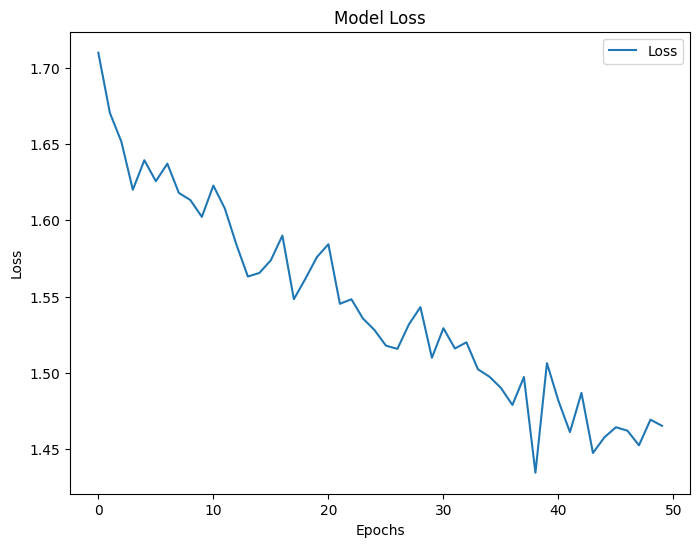

In [10]:
# Plot the training loss
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [11]:
# Save the trained model
model.save('email_generator_model.h5')
print("Model saved successfully!")


Model saved successfully!


In [2]:
from google.colab import files
uploaded = files.upload()  # This will let you upload a file


Saving kaggle.json to kaggle.json


In [3]:
import os
os.listdir('/content')  # This lists all files in the /content directory


['.config', 'kaggle.json', 'sample_data']

In [5]:
import os
from shutil import move

# Create .kaggle folder in /root (required by Kaggle API)
os.makedirs('/root/.kaggle', exist_ok=True)

# Move kaggle.json to the correct location
move('/content/kaggle.json', '/root/.kaggle/kaggle.json')

# Set file permissions to ensure it's accessible
os.chmod('/root/.kaggle/kaggle.json', 600)


In [7]:
!kaggle datasets download -d wcukierski/enron-email-dataset


Dataset URL: https://www.kaggle.com/datasets/wcukierski/enron-email-dataset
License(s): copyright-authors


In [8]:
import zipfile

# Unzip the downloaded dataset
with zipfile.ZipFile('enron-email-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/enron_data')

# Now, you can load the dataset
import pandas as pd
df = pd.read_csv('/content/enron_data/emails.csv')
print(df.head())  # Check the first few rows of the dataset


                       file                                            message
0     allen-p/_sent_mail/1.  Message-ID: <18782981.1075855378110.JavaMail.e...
1    allen-p/_sent_mail/10.  Message-ID: <15464986.1075855378456.JavaMail.e...
2   allen-p/_sent_mail/100.  Message-ID: <24216240.1075855687451.JavaMail.e...
3  allen-p/_sent_mail/1000.  Message-ID: <13505866.1075863688222.JavaMail.e...
4  allen-p/_sent_mail/1001.  Message-ID: <30922949.1075863688243.JavaMail.e...


In [10]:
import re

# Function to clean the text data
def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove non-alphabet characters
    text = text.lower()  # Convert to lowercase
    return text

# Apply the clean_text function to the 'message' column (assuming 'message' is the column containing the text)
df['cleaned_message'] = df['message'].apply(clean_text)

# Preview the cleaned data
print(df.head())  # Check the first few rows of the cleaned data


                       file  \
0     allen-p/_sent_mail/1.   
1    allen-p/_sent_mail/10.   
2   allen-p/_sent_mail/100.   
3  allen-p/_sent_mail/1000.   
4  allen-p/_sent_mail/1001.   

                                             message  \
0  Message-ID: <18782981.1075855378110.JavaMail.e...   
1  Message-ID: <15464986.1075855378456.JavaMail.e...   
2  Message-ID: <24216240.1075855687451.JavaMail.e...   
3  Message-ID: <13505866.1075863688222.JavaMail.e...   
4  Message-ID: <30922949.1075863688243.JavaMail.e...   

                                     cleaned_message  
0  messageid javamailevansthyme\ndate mon  may   ...  
1  messageid javamailevansthyme\ndate fri  may   ...  
2  messageid javamailevansthyme\ndate wed  oct   ...  
3  messageid javamailevansthyme\ndate mon  oct   ...  
4  messageid javamailevansthyme\ndate thu  aug   ...  


In [11]:
# Combine all the cleaned messages into a single string (corpus)
corpus = ' '.join(df['cleaned_message'].values)

# Limit the corpus to the first 1 million characters (optional, based on size)
corpus = corpus[:10**6]  # Adjust if needed


In [12]:
# Create a set of all unique characters in the corpus
chars = sorted(list(set(corpus)))  # Get all unique characters
char_to_int = {ch: i for i, ch in enumerate(chars)}  # Map char to int
int_to_char = {i: ch for i, ch in enumerate(chars)}  # Map int to char

# Preview the character mappings
print(f"Sample character-to-int mapping: {dict(list(char_to_int.items())[:10])}")


Sample character-to-int mapping: {'\t': 0, '\n': 1, ' ': 2, 'a': 3, 'b': 4, 'c': 5, 'd': 6, 'e': 7, 'f': 8, 'g': 9}


In [13]:
# Define the sequence length (number of previous characters to predict the next one)
sequence_length = 50  # You can adjust this based on your dataset

X = []  # List to hold input sequences
y = []  # List to hold output labels (next character)

# Generate input-output sequences
for i in range(0, len(corpus) - sequence_length, 1):
    seq_in = corpus[i:i + sequence_length]  # Input sequence (50 characters)
    seq_out = corpus[i + sequence_length]  # Output (next character)

    # Map each character in the sequence to an integer
    X.append([char_to_int[char] for char in seq_in])
    y.append(char_to_int[seq_out])  # The next character as the target

# Convert X and y to numpy arrays and reshape X
import numpy as np

X = np.reshape(X, (len(X), sequence_length, 1))  # Reshape for LSTM input: [samples, time steps, features]
X = X / float(len(chars))  # Normalize input data (between 0 and 1)

# One-hot encode the output labels (the next character)
from tensorflow.keras.utils import to_categorical

y = to_categorical(y, num_classes=len(chars))

# Display the shapes of X and y
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")


Shape of X: (999950, 50, 1)
Shape of y: (999950, 29)


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam

# Define the LSTM model
model = Sequential()
model.add(LSTM(256, input_shape=(X.shape[1], X.shape[2]), return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(256))
model.add(Dropout(0.2))
model.add(Dense(len(chars), activation='softmax'))  # Output layer with softmax for multi-class classification

from tensorflow.keras.optimizers import Adam

# Correct way to initialize the Adam optimizer in recent versions of Keras
model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001))


# Print the model summary
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 50, 256)             │         264,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 50, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 256)                 │         525,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 29)                  │           7,453 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 796,957 (3.04 MB)

 Trainable params: 796,957 (3.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
15625/15625 ━━━━━━━━━━━━━━━━━━━━ 189s 12ms/step - loss: 2.3327
Epoch 2/50
15625/15625 ━━━━━━━━━━━━━━━━━━━━ 200s 12ms/step - loss: 1.5101
Epoch 3/50
15625/15625 ━━━━━━━━━━━━━━━━━━━━ 202s 12ms/step - loss: 1.3680
Epoch 4/50
15625/15625 ━━━━━━━━━━━━━━━━━━━━ 183s 12ms/step - loss: 1.3147
Epoch 5/50
15625/15625 ━━━━━━━━━━━━━━━━━━━━ 202s 12ms/step - loss: 1.9532
Epoch 6/50
15625/15625 ━━━━━━━━━━━━━━━━━━━━ 203s 12ms/step - loss: 1.7565
Epoch 7/50
15625/15625 ━━━━━━━━━━━━━━━━━━━━ 201s 12ms/step - loss: 1.3964
Epoch 8/50
15625/15625 ━━━━━━━━━━━━━━━━━━━━ 185s 12ms/step - loss: 1.3673
Epoch 9/50
15625/15625 ━━━━━━━━━━━━━━━━━━━━ 183s 12ms/step - loss: 1.4546
Epoch 10/50
15625/15625 ━━━━━━━━━━━━━━━━━━━━ 203s 12ms/step - loss: 1.5545
Epoch 11/50
15625/15625 ━━━━━━━━━━━━━━━━━━━━ 203s 12ms/step - loss: 1.3996
Epoch 12/50
15625/15625 ━━━━━━━━━━━━━━━━━━━━ 201s 12ms/step - loss: 1.3243
Epoch 13/50
15625/15625 ━━━━━━━━━━━━━━━━━━━━ 185s 12ms/step - loss: 1.6357
Epoch 14/50
15625/15625 ━━━━━━━━━━

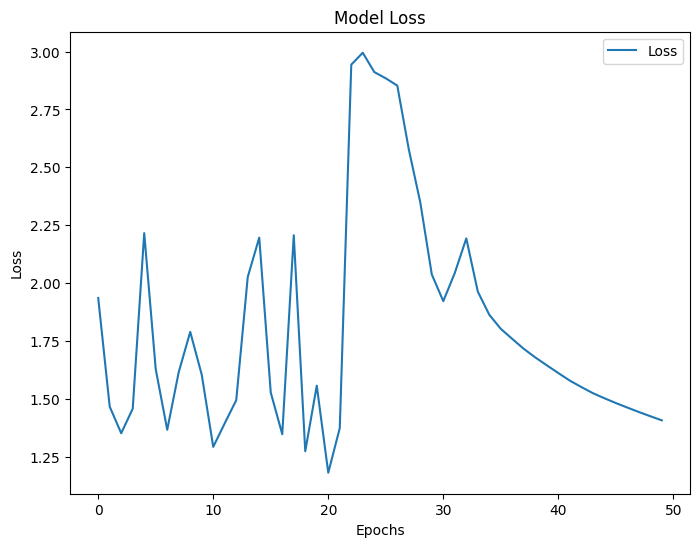

In [16]:
# Train the model (use a smaller batch size and fewer epochs if needed to reduce runtime)
history = model.fit(X, y, epochs=50, batch_size=64, verbose=1)

# Plot the training loss (optional)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [25]:
# Plot validation loss (if available)
if 'val_loss' in history.history:
    plt.figure(figsize=(8, 6))
    plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
    plt.title('Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


In [17]:
model.save('/content/email_generator_model.keras')  # Save as .keras format (recommended by Keras)
print("Model saved successfully!")


Model saved successfully!


In [21]:
import re

# Function to generate text based on a seed
def generate_text(model, seed_text, num_chars=500, sequence_length=50):
    # Lowercase and remove non-alphabet characters from the seed text
    seed_text = re.sub(r'[^a-zA-Z\s]', '', seed_text.lower())

    result = seed_text
    for _ in range(num_chars):
        # Prepare the input for the model (use the last 'sequence_length' characters)
        X_pred = np.array([char_to_int[char] for char in seed_text[-sequence_length:]])  # Get the last 'sequence_length' characters
        X_pred = np.reshape(X_pred, (1, len(X_pred), 1))  # Reshape for prediction
        X_pred = X_pred / float(len(chars))  # Normalize input

        # Predict the next character
        predicted_probs = model.predict(X_pred, verbose=0)  # Predict next character
        predicted_char_index = np.argmax(predicted_probs)  # Choose the most probable character
        predicted_char = int_to_char[predicted_char_index]  # Get the predicted character

        result += predicted_char  # Append predicted character to result
        seed_text += predicted_char  # Add predicted character to seed for next prediction

    return result

# Test the model with a new seed text
seed_text = "Dear valued customer, we are excited to inform you"
generated_text = generate_text(model, seed_text)
print("Generated Marketing Content:\n", generated_text)


Generated Marketing Content:
 dear valued customer we are excited to inform you and the project the project the project the project the project the project the project the project the project the project the project the project the project the project the project the project the project the project the project the project the project the project the project the project the project the project the project the project the project the project the project the project the project the project the project the project the project the project the project the project the project the


In [23]:
import numpy as np
import random

# Function to generate text based on a seed with temperature sampling
def generate_text(model, seed_text, num_chars=500, sequence_length=50, temperature=1.0):
    # Lowercase and remove non-alphabet characters from the seed text
    seed_text = re.sub(r'[^a-zA-Z\s]', '', seed_text.lower())

    result = seed_text
    for _ in range(num_chars):
        # Prepare the input for the model (use the last 'sequence_length' characters)
        X_pred = np.array([char_to_int[char] for char in seed_text[-sequence_length:]])  # Get the last 'sequence_length' characters
        X_pred = np.reshape(X_pred, (1, len(X_pred), 1))  # Reshape for prediction
        X_pred = X_pred / float(len(chars))  # Normalize input

        # Predict the next character
        predicted_probs = model.predict(X_pred, verbose=0)  # Predict next character

        # Apply temperature to predicted probabilities
        predicted_probs = np.squeeze(predicted_probs)
        predicted_probs = np.log(predicted_probs + 1e-7) / temperature  # Log scaling for randomness
        predicted_probs = np.exp(predicted_probs) / np.sum(np.exp(predicted_probs))  # Normalize to get probabilities

        # Sample a character based on the predicted probabilities
        predicted_char_index = np.random.choice(len(chars), p=predicted_probs)
        predicted_char = int_to_char[predicted_char_index]  # Get the predicted character

        result += predicted_char  # Append predicted character to result
        seed_text += predicted_char  # Add predicted character to seed for next prediction

    return result

# Test the model with a new seed text
seed_text = "Dear valued customer, we are excited to inform you"
generated_text = generate_text(model, seed_text, temperature=0.7)  # Use a temperature value (0.7 is more creative)
print("Generated Marketing Content:\n", generated_text)


Generated Marketing Content:
 dear valued customer we are excited to inform you ie leating or the fesess with you please but  of the  tetes linlse ph shan so ie gsom cue so iisittm

                                     
         

	
                                         
      

                                         
                                                

                                                
                                                                                                                       
                                   


In [24]:
# Try different temperature values
generated_text_1 = generate_text(model, seed_text, temperature=0.3)  # Lower temperature
generated_text_2 = generate_text(model, seed_text, temperature=0.7)  # Balanced temperature
generated_text_3 = generate_text(model, seed_text, temperature=1.0)  # Higher temperature

# Print results
print("Generated Text with Temperature 0.3:\n", generated_text_1)
print("\nGenerated Text with Temperature 0.7:\n", generated_text_2)
print("\nGenerated Text with Temperature 1.0:\n", generated_text_3)


Generated Text with Temperature 0.3:
 dear valued customer we are excited to inform you hote the foail in the meeting the sea the puoce whe wear and dasi the desination hn the for a he the 
price and the project and the time the internet in the iise to she fas a meeting the meeting hn the stacini  
                                                                                                                                                                                                                                                                                               

Generated Text with Temperature 0.7:
 dear valued customer we are excited to inform you 
mighaen the stofrse 
         reets forward the nege at the scie ansoe has to ae bi al jn and land appuoved we resuona tr dortall in cbl last drodts manarts what leeping cort of the qoegrt in the lot uhe usate please required eavis hntur and at ase prce stated a costs is see the cvrers fenand than deen fat dterals 
dnur 